In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [64]:
# ================================
# Importing Required Libraries
# ================================

# Pandas
# Used for handling and analyzing structured data
# Helps in reading CSV files, cleaning datasets,
# selecting columns, filtering rows, etc.
import pandas as pd


# NumPy
# Used for numerical computations and mathematical operations
# Provides support for arrays, matrices, statistics, and fast calculations
import numpy as np


# Seaborn
# A data visualization library built on top of Matplotlib
# Used for creating attractive statistical graphs and plots
# Helpful in Exploratory Data Analysis (EDA)
import seaborn as sns


# Matplotlib
# Core plotting library in Python
# Used to create graphs such as line plots, bar charts,
# histograms, scatter plots, etc.
import matplotlib.pyplot as plt


# train_test_split
# Used to divide the dataset into:
# 1. Training data -> used to train the ML model
# 2. Testing data -> used to evaluate model performance
from sklearn.model_selection import train_test_split


# LabelEncoder
# Converts categorical/text data into numerical form
# Example:
# male -> 1
# female -> 0
# Machine Learning models require numerical inputs
from sklearn.preprocessing import LabelEncoder


# LogisticRegression
# A Machine Learning algorithm mainly used for
# classification problems
# In the Titanic dataset:
# Predicts whether a passenger survived or not
from sklearn.linear_model import LogisticRegression


# accuracy_score
# Used to measure how accurate the model predictions are
# Formula:
# Accuracy = Correct Predictions / Total Predictions
from sklearn.metrics import accuracy_score


# Simple confirmation message
print("The libraries are imported successfully!")

The libraries are imported successfully!


Data collection and preprocessing

In [3]:
# ==========================================
# Loading the Titanic Dataset
# ==========================================

# pd.read_csv()
# Used to read a CSV (Comma Separated Values) file
# and convert it into a Pandas DataFrame

# "/kaggle/input/competitions/titanic/train.csv"
# Path of the Titanic training dataset in Kaggle

dataset = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")


# ==========================================
# Viewing the Dataset
# ==========================================

# .head()
# Displays the first 5 rows of the dataset
# Useful for:
# - Understanding the structure of data
# - Checking column names
# - Inspecting sample values
# - Verifying dataset loaded correctly

dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


"surevived" : 0 -> died 1-> survived
"sex" : (male/female)


In [4]:
# ==========================================
# Checking the Shape of the Dataset
# ==========================================

# .shape
# Returns the dimensions of the dataset
# in the form:
# (number_of_rows, number_of_columns)

# Rows    -> Total number of records/passengers
# Columns -> Total number of features/attributes

dataset.shape

(891, 12)

In [5]:
# ==========================================
# Getting Information About the Dataset
# ==========================================

# .info()
# Displays a summary of the dataset

# It provides:
# 1. Total number of rows and columns
# 2. Column names
# 3. Number of non-null (non-missing) values
# 4. Data type of each column
# 5. Memory usage of the dataset

# This is very useful for:
# - Identifying missing values
# - Understanding data types
# - Planning data preprocessing steps
# - Detecting columns that need encoding or cleaning

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# ==========================================
# Checking Missing (Null) Values
# ==========================================

# .isnull()
# Checks every cell in the dataset
# Returns:
# True  -> if the value is missing (NaN)
# False -> if the value exists

# .sum()
# Counts the total number of missing values
# in each column

# This helps us identify:
# - Which columns contain missing data
# - How many values are missing
# - What preprocessing steps are needed

dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
# ==========================================
# Handling Missing Values
# ==========================================

# The 'Cabin' column contains a large number
# of missing (null) values in the Titanic dataset.
# Since most of the values are missing,
# this column may not be very useful for training
# the Machine Learning model.

# drop()
# Used to remove rows or columns from the dataset

# columns=['Cabin']
# Specifies that we want to remove the 'Cabin' column

# inplace=True
# Makes the changes directly in the original dataset
# without needing to reassign it

dataset.drop(columns=['Cabin'], inplace=True)

KeyError: "['Cabin'] not found in axis"

In [18]:
# ==========================================
# Filling Missing Values in the 'Age' Column
# ==========================================

# The 'Age' column in the Titanic dataset
# contains several missing (NaN) values.
# Machine Learning models cannot work properly
# with missing numerical data, so we replace them.

# dataset['Age'].mean()
# Calculates the average age of all passengers

# fillna()
# Replaces missing (NaN) values with a specified value

# Here:
# Every missing age value is replaced with
# the average age of passengers

dataset['Age'] = dataset['Age'].fillna(dataset['Age'].mean())

In [19]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [25]:
# ==========================================
# Filling Missing Values in the 'Embarked' Column
# ==========================================

# The 'Embarked' column contains a few missing values.
# 'Embarked' represents the port from which
# the passenger boarded the ship.

# Since 'Embarked' is a categorical/text column,
# using mean or median is not possible.

# mode()
# Returns the most frequently occurring value
# in the column

# Example:
# If most passengers boarded from 'S',
# then the mode will be 'S'

mode_embarked = dataset['Embarked'].mode()


# fillna()
# Replaces missing (NaN) values

# mode_embarked[0]
# mode() returns a Series,
# so we take the first most frequent value

dataset['Embarked'] = dataset['Embarked'].fillna(mode_embarked[0])

In [26]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Exploratory data analysis

In [27]:
# ==========================================
# Statistical Summary of the Dataset
# ==========================================

# .describe()
# Generates statistical information
# for all numerical columns in the dataset

# It provides:
# 1. count -> Number of non-missing values
# 2. mean  -> Average value
# 3. std   -> Standard deviation
# 4. min   -> Minimum value
# 5. 25%   -> First quartile
# 6. 50%   -> Median value
# 7. 75%   -> Third quartile
# 8. max   -> Maximum value

# This helps us:
# - Understand data distribution
# - Detect outliers
# - Analyze ranges of values
# - Verify preprocessing results

dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Survived
0    549
1    342
Name: count, dtype: int64

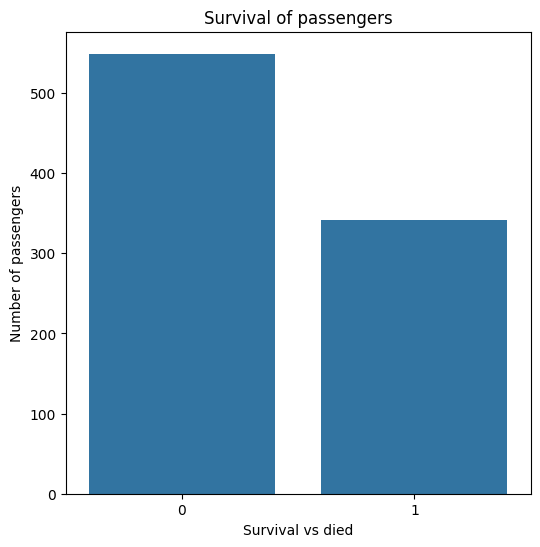

In [33]:
# ==========================================
# Visualizing Survival Distribution
# ==========================================

# We are creating a count plot to visualize:
# - How many passengers survived
# - How many passengers died

# In the Titanic dataset:
# 0 -> Passenger died
# 1 -> Passenger survived


# Creating the figure size
# figsize=(6,6)
# Sets the width and height of the graph

plt.figure(figsize=(6,6))


# sns.countplot()
# Creates a bar chart showing the count
# of each category in the 'Survived' column

# x='Survived'
# Uses the 'Survived' column on the x-axis

# data=dataset
# Specifies the dataset to use

sns.countplot(x='Survived', data=dataset)


# Setting the graph title
plt.title("Survival of Passengers")


# Label for x-axis
plt.xlabel("0 = Died, 1 = Survived")


# Label for y-axis
plt.ylabel("Number of Passengers")


# Displaying the graph
plt.show()


# ==========================================
# Counting Survival Values
# ==========================================

# value_counts()
# Counts how many times each value appears
# in the 'Survived' column

# Output:
# 0 -> Number of passengers who died
# 1 -> Number of passengers who survived

dataset['Survived'].value_counts()

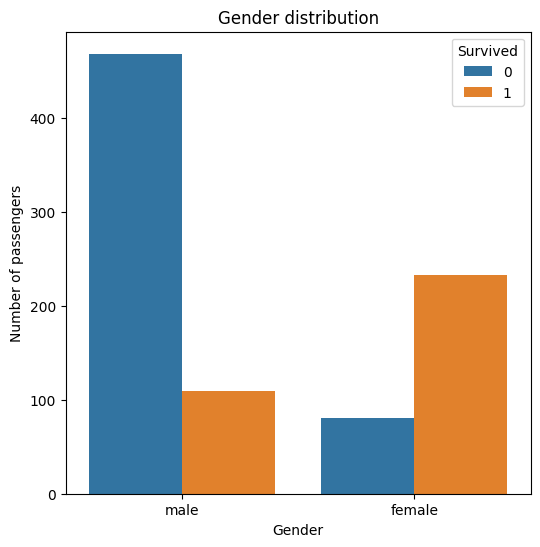

In [35]:
# ==========================================
# Gender-wise Survival Distribution
# ==========================================

# This graph helps us analyze:
# - Number of male and female passengers
# - How many survived and how many died
# based on gender

# In the graph:
# Different colors represent survival status
# 0 -> Died
# 1 -> Survived


# Creating the figure size
plt.figure(figsize=(6,6))


# sns.countplot()
# Creates a count-based bar chart

# x='Sex'
# Gender categories will appear on the x-axis
# (male and female)

# hue='Survived'
# Splits each gender category based on survival status

# data=dataset
# Specifies the dataset being used

sns.countplot(x='Sex', hue='Survived', data=dataset)


# Setting the graph title
plt.title("Gender Survival Distribution")


# Label for x-axis
plt.xlabel("Gender")


# Label for y-axis
plt.ylabel("Number of Passengers")


# Displaying the graph
plt.show()

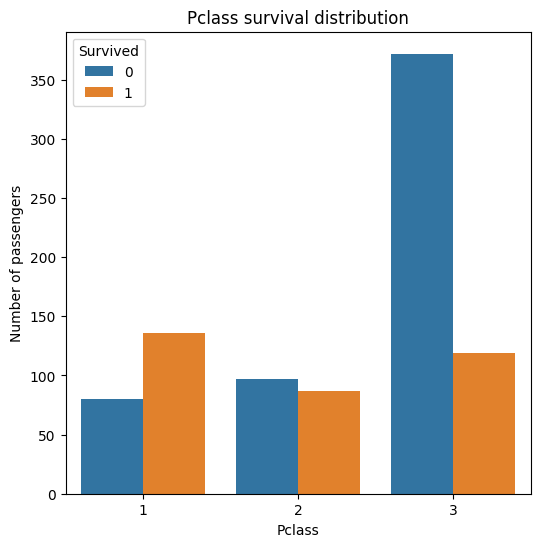

In [36]:
# ==========================================
# Passenger Class vs Survival Distribution
# ==========================================

# This graph helps us understand:
# - How survival rates vary across passenger classes
# - Whether higher-class passengers had a better
#   chance of survival

# In the Titanic dataset:
# Pclass values represent:
# 1 -> First Class
# 2 -> Second Class
# 3 -> Third Class

# hue='Survived'
# Separates passengers based on survival status:
# 0 -> Died
# 1 -> Survived


# Creating the figure size
plt.figure(figsize=(6,6))


# sns.countplot()
# Creates a bar chart showing passenger counts

# x='Pclass'
# Passenger class displayed on the x-axis

# hue='Survived'
# Splits each class into survived and died categories

# data=dataset
# Dataset used for plotting

sns.countplot(x='Pclass', hue='Survived', data=dataset)


# Setting the graph title
plt.title("Pclass Survival Distribution")


# Label for x-axis
plt.xlabel("Passenger Class")


# Label for y-axis
plt.ylabel("Number of Passengers")


# Displaying the graph
plt.show()

Encoding the categorical values

In [47]:
# ==========================================
# Encoding Categorical Columns
# ==========================================

# Machine Learning models cannot directly
# understand text/categorical values.
# So we convert categorical data into numbers.

# LabelEncoder
# Converts text labels into numerical values

# Example:
# male   -> 1
# female -> 0

# Creating the LabelEncoder object
encoder = LabelEncoder()


# ==========================================
# Encoding the 'Sex' Column
# ==========================================

# fit_transform()
# 1. Finds unique categories
# 2. Converts them into numerical labels

dataset['Sex'] = encoder.fit_transform(dataset['Sex'])


# ==========================================
# Encoding the 'Embarked' Column
# ==========================================

# Embarked contains values like:
# S -> Southampton
# C -> Cherbourg
# Q -> Queenstown

# These are converted into numbers
# so the ML model can process them

dataset['Embarked'] = encoder.fit_transform(dataset['Embarked'])


# ==========================================
# Viewing the Last 5 Rows
# ==========================================

# .tail()
# Displays the last 5 rows of the dataset
# Useful for checking whether encoding
# was applied correctly

dataset.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
886,887,0,2,"Montvila, Rev. Juozas",1,27.000000,0,0,211536,13.00,2
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.000000,0,0,112053,30.00,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,29.699118,1,2,W./C. 6607,23.45,2
889,890,1,1,"Behr, Mr. Karl Howell",1,26.000000,0,0,111369,30.00,0
890,891,0,3,"Dooley, Mr. Patrick",1,32.000000,0,0,370376,7.75,1


features and Target

In [49]:
# ==========================================
# Separating Features and Target Variable
# ==========================================

# In Machine Learning:
# X -> Input features (independent variables)
# y -> Target/output variable (dependent variable)

# The model learns patterns from X
# and predicts y


# ==========================================
# Creating Feature Variables (X)
# ==========================================

# drop()
# Removes unnecessary columns from the dataset

# We are removing:
# 1. 'Survived'
#    -> This is the target column
#       and should not be included in input features

# 2. 'Ticket'
#    -> Mostly unique ticket values
#       not very useful for prediction

# 3. 'PassengerId'
#    -> Just an identification number
#       does not help the model learn patterns

# 4. 'Name'
#    -> Text data with unique passenger names
#       difficult to use directly in this model

# The remaining columns become input features

x = dataset.drop(
    columns=['Survived', 'Ticket', 'PassengerId', 'Name'],
    axis=1
)


# ==========================================
# Creating Target Variable (y)
# ==========================================

# The model will try to predict
# whether a passenger survived or not

# 0 -> Died
# 1 -> Survived

y = dataset['Survived']

training and testing

In [54]:
# ==========================================
# Splitting the Dataset into Training and Testing Data
# ==========================================

# train_test_split()
# Used to divide the dataset into:
# 1. Training data -> used to train the ML model
# 2. Testing data  -> used to evaluate model performance

# x
# Input features (independent variables)

# y
# Target variable (Survived column)

# test_size=0.2
# 20% of the data is used for testing
# 80% is used for training

# Example:
# If dataset has 100 rows:
# 80 rows -> training
# 20 rows -> testing

# random_state=12
# Ensures reproducibility
# The split will remain the same
# every time the code is executed

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    random_state=12,
    test_size=0.2
)

Logistic Regression model training

In [58]:
# ==========================================
# Creating and Training the Logistic Regression Model
# ==========================================

# LogisticRegression()
# Creates a Logistic Regression Machine Learning model

# Logistic Regression is mainly used for:
# - Binary classification problems
# - Predicting two possible outcomes

# In the Titanic dataset:
# 0 -> Passenger did not survive
# 1 -> Passenger survived

# The model learns patterns from the training data
# and tries to predict survival based on features
# such as:
# - Age
# - Sex
# - Passenger class
# - Fare
# etc.

model = LogisticRegression()


# ==========================================
# Training the Model
# ==========================================

# fit()
# Trains the Machine Learning model

# x_train
# Input features used for training

# y_train
# Correct output labels corresponding
# to the training data

# During training:
# The model finds relationships between
# passenger features and survival outcomes

model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Model Evaluation

In [60]:
# ==========================================
# Predicting on Training Data
# ==========================================

# predict()
# Used to make predictions using the trained model

# x_train
# Training feature data given to the model

# The model predicts:
# 0 -> Passenger did not survive
# 1 -> Passenger survived

train_prediction = model.predict(x_train)


# ==========================================
# Calculating Training Accuracy
# ==========================================

# accuracy_score()
# Measures how many predictions were correct

# Parameters:
# 1. train_prediction -> Predicted values by the model
# 2. y_train          -> Actual correct values

# Formula:
# Accuracy = Correct Predictions / Total Predictions

train_accuracy = accuracy_score(train_prediction, y_train)


# ==========================================
# Displaying the Accuracy
# ==========================================

# Prints the accuracy score of the model
# on the training dataset

print("The accuracy score of the training data: ", train_accuracy)

The accuracy score of the training data:  0.800561797752809


In [62]:
# ==========================================
# Predicting on Testing Data
# ==========================================

# predict()
# Uses the trained Logistic Regression model
# to make predictions on unseen test data

# x_test
# Feature data reserved for testing

# The model predicts:
# 0 -> Passenger did not survive
# 1 -> Passenger survived

test_prediction = model.predict(x_test)


# ==========================================
# Calculating Testing Accuracy
# ==========================================

# accuracy_score()
# Compares:
# 1. Predicted values by the model
# 2. Actual correct values from the dataset

# This tells us how well the model performs
# on unseen data

test_accuracy = accuracy_score(test_prediction, y_test)


# ==========================================
# Displaying the Testing Accuracy
# ==========================================

print("The accuracy score of the testing data: ", test_accuracy)

The accuracy score of the testing data:  0.7988826815642458
